<a href="https://colab.research.google.com/github/TylerBFabela/custom-and-pretrained-CNN-for-car-make-identification/blob/main/ClipFilterForImageProcessing_CustomCNNToIdentifyCarMake_PretrainedCNNToCompareAgainstCustomCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Using a Clip Filter to Get the Necessary 10,000 images for training and testing

This Clip Filter should be able to
In order to use, create a file called Colab_Data in your Google Drive \(not in any additional folders, just in "My Drive"\) and have the dataset (60k+ images with class name in the name of the image \[ex. "Acura\_..._#.jpg"\]) in a zip file called "total_vehicles.zip" (download the zip from Kaggle, relocate the file, and rename the file). This will end up saving the filtered images (10,000 of them) in a file called "vehicles.zip"

Mounted at /content/drive
Extracting total_vehicles.zip...


/tmp/ipykernel_4573/1865623136.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_initial, x='Make', order=df_initial['Make'].value_counts().index, palette="viridis")


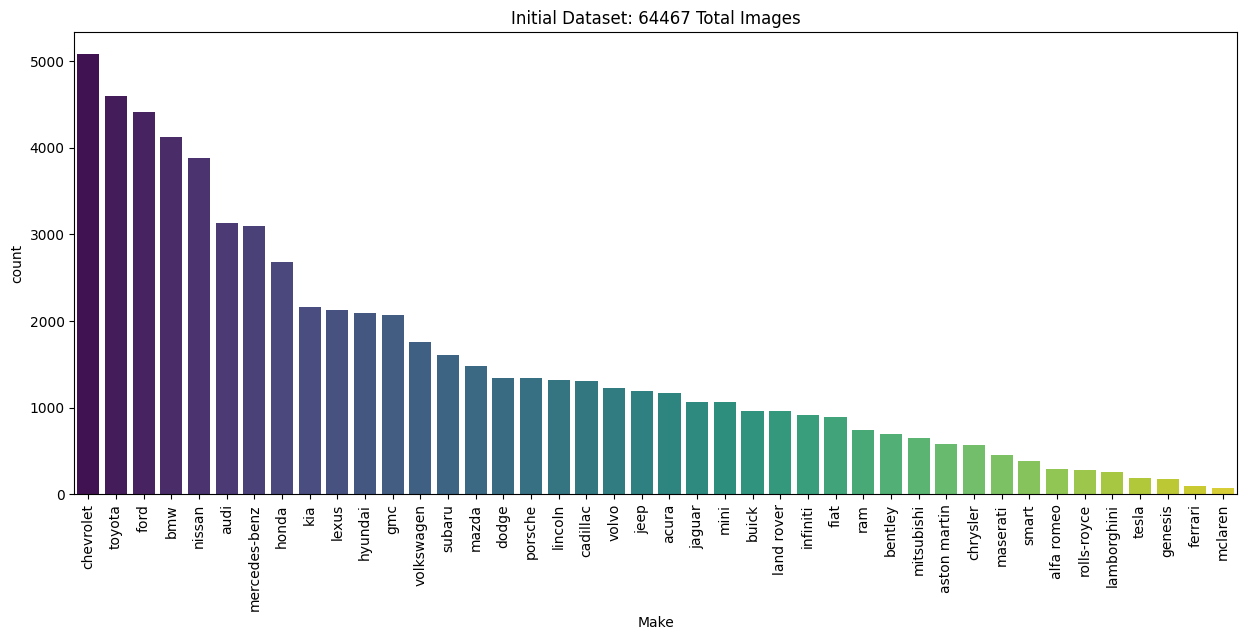

In [ ]:
# Step 1 - Link up to Google Drive

from google.colab import drive
import os
import shutil
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# links up to Google Drive
drive.mount('/content/drive')
SOURCE_ZIP = "/content/drive/MyDrive/Colab_Data/total_vehicles.zip"
LOCAL_RAW = "/content/raw_images"

if os.path.exists(LOCAL_RAW): shutil.rmtree(LOCAL_RAW)
os.makedirs(LOCAL_RAW, exist_ok=True)

# Unzip
print("Extracting total_vehicles.zip...")
with zipfile.ZipFile(SOURCE_ZIP, 'r') as zip_ref:
    zip_ref.extractall(LOCAL_RAW)

# Interpret Data: Images to Classes
all_files = [f for f in os.listdir(LOCAL_RAW) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
initial_makes = [f.split('_')[0].lower() for f in all_files]
df_initial = pd.DataFrame({'Make': initial_makes})

# Visualization for Users
plt.figure(figsize=(15, 6))
sns.countplot(data=df_initial, x='Make', order=df_initial['Make'].value_counts().index, palette="viridis")
plt.xticks(rotation=90)
plt.title(f"Initial Dataset: {len(all_files)} Total Images")
plt.show()

In [ ]:
# Step 2 - Use CLIP filter

!pip install git+https://github.com/openai/CLIP.git

import torch
import clip
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

EXTERIOR_DIR = "/content/exterior_only"
if os.path.exists(EXTERIOR_DIR): shutil.rmtree(EXTERIOR_DIR)
os.makedirs(EXTERIOR_DIR, exist_ok=True)

# CLIP Setup
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
clip_model, clip_preprocess = clip.load("ViT-B/32", device=DEVICE)

# Prompts
ext_prompts = ["a photo of a car exterior", "a full car body shot", "a vehicle parked on a street", "the side profile of a car"]
int_prompts = ["a car interior", "dashboard of a car", "inside a car cabin", "steering wheel and console"]
jnk_prompts = ["a car logo", "a close up of a headlight", "a car tire", "a drawing of a car"]

def get_group_features(prompts):
    tokens = clip.tokenize(prompts).to(DEVICE)
    with torch.no_grad():
        feats = clip_model.encode_text(tokens)
        feats /= feats.norm(dim=-1, keepdim=True)
    return feats.mean(dim=0, keepdim=True)

ext_feat, int_feat, jnk_feat = get_group_features(ext_prompts), get_group_features(int_prompts), get_group_features(jnk_prompts)

class CarDataset(Dataset):
    def __init__(self, paths, transform):
        self.paths = paths
        self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        try: return self.transform(Image.open(self.paths[idx]).convert("RGB")), self.paths[idx]
        except: return torch.zeros(3, 224, 224), "error"

all_paths = [os.path.join(LOCAL_RAW, f) for f in all_files]
loader = DataLoader(CarDataset(all_paths, clip_preprocess), batch_size=128, num_workers=2)

print("Scoring images using CLIP similarity... Please wait...")
scored_data = []

for imgs, paths in tqdm(loader):
    imgs = imgs.to(DEVICE)
    with torch.no_grad():
        img_feat = clip_model.encode_image(imgs)
        img_feat /= img_feat.norm(dim=-1, keepdim=True)

        s_ext = (img_feat @ ext_feat.T).cpu().numpy().flatten()
        s_int = (img_feat @ int_feat.T).cpu().numpy().flatten()
        s_jnk = (img_feat @ jnk_feat.T).cpu().numpy().flatten()

    for i, path in enumerate(paths):
        if path == "error": continue

        quality_score = s_ext[i] - max(s_int[i], s_jnk[i])

        make = os.path.basename(path).split('_')[0].lower()
        scored_data.append({
            'path': path,
            'make': make,
            'score': quality_score
        })

df_scores = pd.DataFrame(scored_data)
print(f"\nScoring complete for {len(df_scores)} images.")

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-qnquz1up
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-qnquz1up
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.3 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=91c5a73066a29863b2504c65dfb85e0853606e3a11a4ebe6a20fd71e6d0601f5
  Stored in directory: /tmp/pip-ephem-wheel-cache-7euo7hmm/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


100%|████████████████████████████████████████| 338M/338M [00:00<00:00, 470MiB/s]


Scoring images via CLIP similarity...


100%|██████████| 504/504 [01:56<00:00,  4.34it/s]


Scoring complete for 64467 images.


Found 37 makes with at least 250 images.
Copying 9250 images to /content/final_dataset...


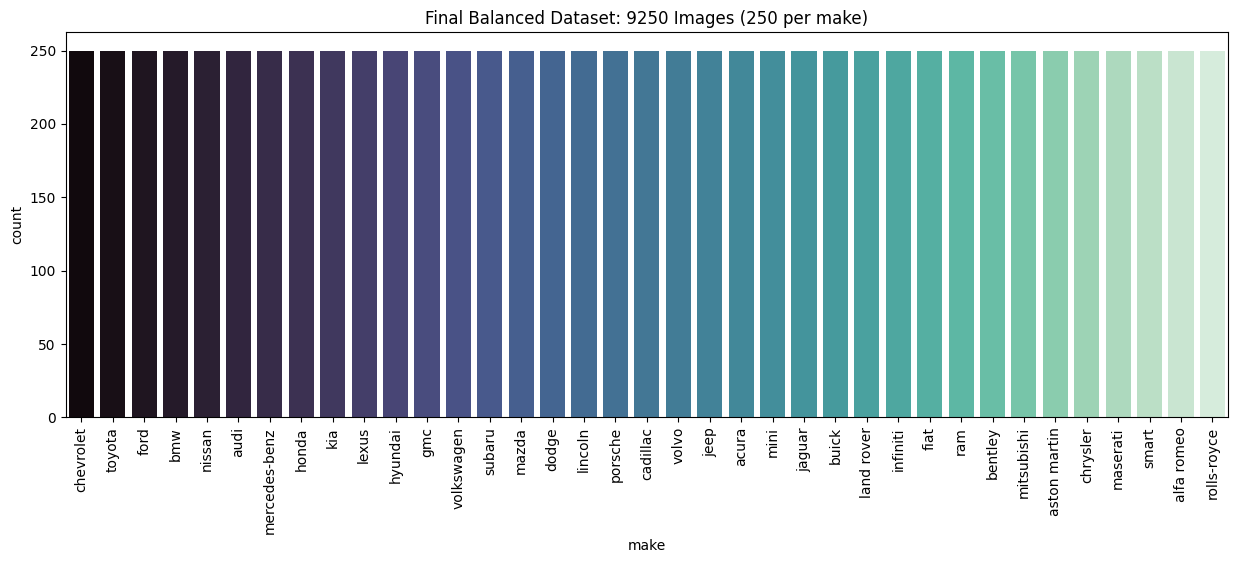

Zipping and moving to Drive...
Success! 'vehicles.zip' exported.


In [ ]:
# Step 3 - Get and Zip 10,000 Needed Images

import shutil

FINAL_DIR = "/content/final_dataset"
if os.path.exists(FINAL_DIR): shutil.rmtree(FINAL_DIR)
os.makedirs(FINAL_DIR, exist_ok=True)

# Requirements of Zip
IMAGES_PER_MAKE = 250
MIN_THRESHOLD_SCORE = -0.05
TOTAL_GOAL = 10000

df_filtered = df_scores[df_scores['score'] > MIN_THRESHOLD_SCORE]

make_counts = df_filtered['make'].value_counts()
valid_makes = make_counts[make_counts >= IMAGES_PER_MAKE].index.tolist()

print(f"Found {len(valid_makes)} makes with at least {IMAGES_PER_MAKE} images.")

final_selection = []
for make in valid_makes:
    top_images = df_filtered[df_filtered['make'] == make].sort_values(by='score', ascending=False).head(IMAGES_PER_MAKE)
    final_selection.append(top_images)

if final_selection:
    df_final = pd.concat(final_selection)

    if len(df_final) > TOTAL_GOAL:
        target_makes = TOTAL_GOAL // IMAGES_PER_MAKE
        selected_makes = valid_makes[:target_makes]
        df_final = df_final[df_final['make'].isin(selected_makes)]

    print(f"Copying {len(df_final)} images to {FINAL_DIR}...")
    for _, row in df_final.iterrows():
        shutil.copy(row['path'], os.path.join(FINAL_DIR, os.path.basename(row['path'])))

    # Visuals for Users to Verify Dataset Distribution
    plt.figure(figsize=(15, 5))
    sns.countplot(x=df_final['make'], hue=df_final['make'], palette="mako", legend=False)
    plt.xticks(rotation=90)
    plt.title(f"Final Balanced Dataset: {len(df_final)} Images ({IMAGES_PER_MAKE} per make)")
    plt.show()

    # Zip and Export File to Google Drive
    print("Zipping and moving to Drive...")
    !zip -j -q /content/vehicles.zip {FINAL_DIR}/*
    !cp /content/vehicles.zip /content/drive/MyDrive/Colab_Data/vehicles.zip
    print("Success! 'vehicles.zip' exported.")
else:
    print("Parsing flunked, need better prompting/more lenient scoring.")

# CNN to Identify Car Make, Model, Year, and Color

This Custom CNN should get a training/validation/testing of about \~90%/\~64%/\~64%
In order to use, create a file called Colab_Data in your Google Drive \(not in any additional folders, just in "My Drive"\) and have the dataset (10k images with class name in the name of the image \[ex. "Acura\_..._#.jpg"\]) in a zip file called "vehicles.zip". You should be able to save the model as a file if need be.

In [1]:
# Step 1 - Get ZIP from Google Drive and parse image text

from google.colab import drive
import os
import zipfile
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

drive.mount('/content/drive')
zip_path = '/content/drive/MyDrive/Colab_Data/vehicles.zip'
extract_dir = '/content/dataset'

# Unzip
if not os.path.exists(extract_dir):
    os.makedirs(extract_dir)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

image_folder = extract_dir
filepaths, makes = [], []

for filename in os.listdir(image_folder):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
        parts = filename.split('_')
        if len(parts) >= 1:
            filepaths.append(os.path.join(image_folder, filename))
            makes.append(parts[0].lower())

df = pd.DataFrame({'filepath': filepaths, 'Make': makes})

# make sure dataset per class is large enough (should be about 250 images each)
min_samples = 200
counts = df['Make'].value_counts()
df = df[df['Make'].isin(counts[counts >= min_samples].index)]

print(f"Total images after filtering: {len(df)}")
print(f"Unique Makes to classify after filtering: {df['Make'].nunique()}")

Mounted at /content/drive
Total images after filtering: 9250
Unique Makes to classify after filtering: 37


In [18]:
# Step 2 - set up training, validation, and testing; data augmentation

from sklearn.model_selection import train_test_split

# Training, Validation, and Testing Split
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['Make'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['Make'])

print(f"Training samples:   {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Testing samples:    {len(test_df)}")

batch_size = 64
img_size = (192, 192)

# Training Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest',
    shear_range=0.1,
    brightness_range=[0.75, 1.25]
)

# Validation Augmentation
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df, x_col='filepath', y_col='Make',
    target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=True
)

val_gen = val_test_datagen.flow_from_dataframe(
    dataframe=val_df, x_col='filepath', y_col='Make',
    target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=False
)

test_gen = val_test_datagen.flow_from_dataframe(
    dataframe=test_df, x_col='filepath', y_col='Make',
    target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=False
)

num_classes = df['Make'].nunique()

Training samples:   7400
Validation samples: 925
Testing samples:    925
Found 7400 validated image filenames belonging to 37 classes.
Found 925 validated image filenames belonging to 37 classes.
Found 925 validated image filenames belonging to 37 classes.


In [19]:
# Step 3 - Create Custom CNN

from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D, GlobalMaxPooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras import regularizers

def build_custom_cnn():
    inputs = Input(shape=(img_size[0], img_size[1], 3))

    # 5 Convolutional Layers
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(512, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    x = GlobalAveragePooling2D()(x)

    # 1 Dense Layer
    x = Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.0001))(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)
    return model

model = build_custom_cnn()
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# User Reassurance
print("Pretrained MobileNetV2 Model Built Successfully!")
model.summary()

Pretrained MobileNetV2 Model Built Successfully!


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 192, 192, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 192, 192, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 192, 192, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 96, 96, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 96, 96, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 96, 96, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 48, 48, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 48, 48, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 12, 12, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 37)             │        18,981 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,854,181 (7.07 MB)

 Trainable params: 1,852,197 (7.07 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [20]:
# Step 4 - Fine-Tuning and Training

from sklearn.utils import class_weight

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True, monitor='val_loss'),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5, monitor='val_loss'),
    tf.keras.callbacks.ModelCheckpoint('best_make_model.keras', save_best_only=True)
]

# Class Weights
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weight_dict = dict(enumerate(class_weights_array))
print("Class weights successfully calculated!")

# Training
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

Class weights successfully calculated!
Epoch 1/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 85s 649ms/step - accuracy: 0.0428 - loss: 3.7305 - val_accuracy: 0.0270 - val_loss: 4.2906 - learning_rate: 0.0010
Epoch 2/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 69s 596ms/step - accuracy: 0.0569 - loss: 3.6364 - val_accuracy: 0.0259 - val_loss: 4.4762 - learning_rate: 0.0010
Epoch 3/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 68s 583ms/step - accuracy: 0.0588 - loss: 3.6034 - val_accuracy: 0.0281 - val_loss: 4.7284 - learning_rate: 0.0010
Epoch 4/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 69s 592ms/step - accuracy: 0.0664 - loss: 3.5883 - val_accuracy: 0.0389 - val_loss: 3.9486 - learning_rate: 0.0010
Epoch 5/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 69s 595ms/step - accuracy: 0.0692 - loss: 3.5658 - val_accuracy: 0.0757 - val_loss: 3.5662 - learning_rate: 0.0010
Epoch 6/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 69s 592ms/step - accuracy: 0.0747 - loss: 3.5366 - val_accuracy: 0.0941 - val_loss: 3.5034 - learning_rate: 0.0010
Epoch 7/50
116/116 ━━━━━━━━━━━━

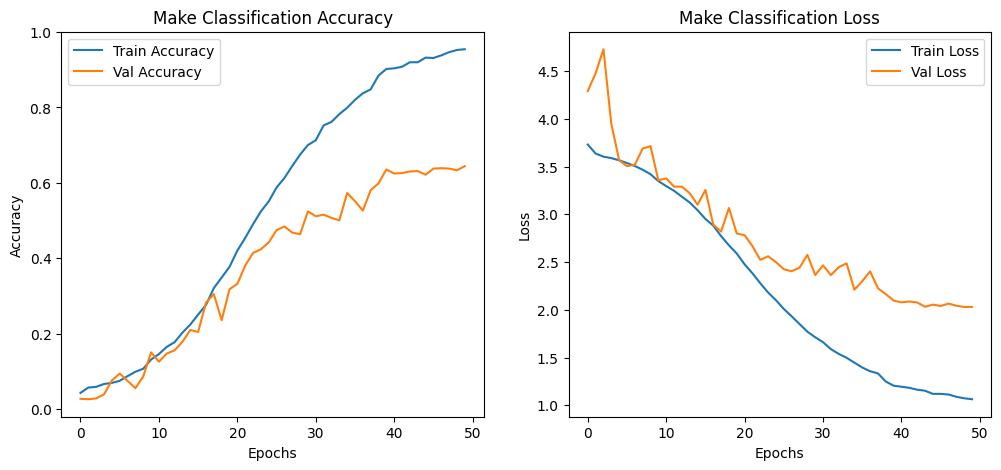


---Testing---
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.6184 - loss: 2.1173
Overall Test Loss: 2.1173
Overall Test Accuracy: 61.84%

15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step
--- Classification Report ---
               precision    recall  f1-score   support

        acura       0.74      0.68      0.71        25
   alfa romeo       0.76      0.64      0.70        25
 aston martin       0.43      0.72      0.54        25
         audi       0.39      0.44      0.42        25
      bentley       0.50      0.68      0.58        25
          bmw       0.50      0.56      0.53        25
        buick       0.70      0.64      0.67        25
     cadillac       0.68      0.76      0.72        25
    chevrolet       0.86      0.48      0.62        25
     chrysler       0.85      0.92      0.88        25
        dodge       0.46      0.48      0.47        25
         fiat       0.81      0.84      0.82        25
         ford       0.55      0.44      0.49        25
          gm

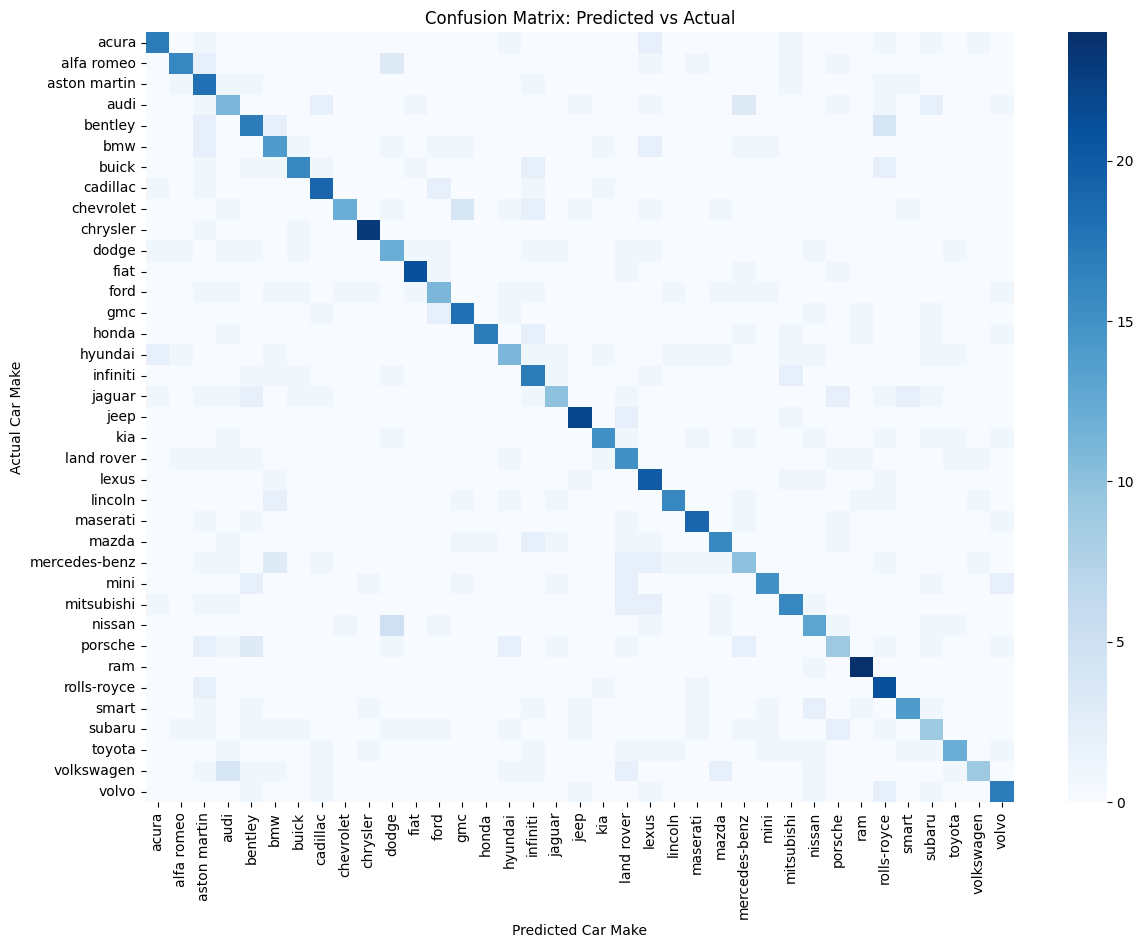

In [21]:
# Step 5 - Print out results

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Make Classification Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Make Classification Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Testing
print("\n---Testing---")
test_results = model.evaluate(test_gen)
print(f"Overall Test Loss: {test_results[0]:.4f}")
print(f"Overall Test Accuracy: {test_results[1]*100:.2f}%\n")

test_gen.reset()

# Print out model's precision, recall, and f1-measures
y_pred_probs = model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

class_labels = list(test_gen.class_indices.keys())

print("--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Confusion Matrix Visuals
print("\n---Confusion Matrix for Testing---")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix: Predicted vs Actual')
plt.xlabel('Predicted Car Make')
plt.ylabel('Actual Car Make')
plt.show()

In [31]:
# Step 6 - Save the Model

import numpy as np

model.save("car_make_identifier_custom_cnn_model.keras")

# Pretrained Model

This Pretrained CNN uses transfer learning from MobileNetV2 and should get a training/validation/testing of about \~95%/\~70%/\~70%
In order to use, create a file called Colab_Data in your Google Drive \(not in any additional folders, just in "My Drive"\) and have the dataset (10k images with class name in the name of the image \[ex. "Acura\_..._#.jpg"\]) in a zip file called "vehicles.zip". You should be able to save the model as a file if need be.

In [22]:
# Step 1 - Get ZIP from Google Drive and parse image text

from google.colab import drive
import os
import zipfile
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

drive.mount('/content/drive')
zip_path = '/content/drive/MyDrive/Colab_Data/vehicles.zip'
extract_dir = '/content/dataset'

# Unzip
if not os.path.exists(extract_dir):
   os.makedirs(extract_dir)
   with zipfile.ZipFile(zip_path, 'r') as zip_ref:
       zip_ref.extractall(extract_dir)

image_folder = extract_dir
filepaths, makes = [], []

for filename in os.listdir(image_folder):
   if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
       parts = filename.split('_')
       if len(parts) >= 1:
           filepaths.append(os.path.join(image_folder, filename))
           makes.append(parts[0].lower())

df = pd.DataFrame({'filepath': filepaths, 'Make': makes})

# make sure dataset per class is large enough (should be about 250 images each)
min_samples = 200
counts = df['Make'].value_counts()
df = df[df['Make'].isin(counts[counts >= min_samples].index)]

print(f"Total images after filtering: {len(df)}")
print(f"Unique Makes to classify after filtering: {df['Make'].nunique()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total images after filtering: 9250
Unique Makes to classify after filtering: 37


In [23]:
# Step 2 - set up training, validation, and testing; data augmentation

from sklearn.model_selection import train_test_split
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Training, Validation, and Testing Split
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['Make'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['Make'])

print(f"Training samples:   {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Testing samples:    {len(test_df)}")

batch_size = 64
img_size = (224, 224)

# Training Augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest',
    shear_range=0.1,
    brightness_range=[0.75, 1.25]
)

# Validation Augmentation
val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_dataframe(
   dataframe=train_df, x_col='filepath', y_col='Make',
   target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=True
)

val_gen = val_test_datagen.flow_from_dataframe(
   dataframe=val_df, x_col='filepath', y_col='Make',
   target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=False
)

test_gen = val_test_datagen.flow_from_dataframe(
   dataframe=test_df, x_col='filepath', y_col='Make',
   target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=False
)

num_classes = df['Make'].nunique()

Training samples:   7400
Validation samples: 925
Testing samples:    925
Found 7400 validated image filenames belonging to 37 classes.
Found 925 validated image filenames belonging to 37 classes.
Found 925 validated image filenames belonging to 37 classes.


In [24]:
# Step 3 - Pretrained MobileNetV2

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers

def build_transfer_model():
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_size[0], img_size[1], 3))
    base_model.trainable = False

    inputs = Input(shape=(img_size[0], img_size[1], 3))
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)

    # 1 Dense Layer
    x = Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = Dropout(0.5)(x)

    outputs = Dense(num_classes, activation='softmax')(x)
    return Model(inputs=inputs, outputs=outputs), base_model

model, base_model = build_transfer_model()

model.compile(
   optimizer='adam',
   loss='categorical_crossentropy',
   metrics=['accuracy']
)

# User Reassurance
print("Pretrained MobileNetV2 Model Built Successfully!")
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Pretrained MobileNetV2 Model Built Successfully!


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 37)             │        18,981 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,932,837 (11.19 MB)

 Trainable params: 674,853 (2.57 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [25]:
# Step 4 - Fine-Tuning And Training Pretrained Model

from sklearn.utils import class_weight
import tensorflow as tf
import numpy as np

class_weights_array = class_weight.compute_class_weight(
   class_weight='balanced',
   classes=np.unique(train_gen.classes),
   y=train_gen.classes
)
class_weight_dict = dict(enumerate(class_weights_array))

# Phase 1
print("--- Phase 1: Warming up the classification head ---")

base_model.trainable = False

model.compile(
   optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
   loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
   metrics=['accuracy']
)

history_warmup = model.fit(
   train_gen,
   validation_data=val_gen,
   epochs=10,
   class_weight=class_weight_dict
)

# Phase 2
print("\n--- Phase 2: Unfreezing middle/top layers and fine-tuning ---")

base_model.trainable = True

for layer in base_model.layers[:50]:
   layer.trainable = False

model.compile(
   optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
   loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
   metrics=['accuracy']
)

# Callbacks
callbacks = [
   tf.keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True, monitor='val_loss'),
   tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5, monitor='val_loss'),
   tf.keras.callbacks.ModelCheckpoint('best_pretrained_model.keras', save_best_only=True)
]

# Train Model
history_fine_tuned = model.fit(
   train_gen,
   validation_data=val_gen,
   epochs=30,
   callbacks=callbacks,
   class_weight=class_weight_dict
)

--- Phase 1: Warming up the classification head ---
Epoch 1/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.0914 - loss: 4.0993 - val_accuracy: 0.1881 - val_loss: 3.6283
Epoch 2/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 92s 792ms/step - accuracy: 0.1693 - loss: 3.6196 - val_accuracy: 0.2324 - val_loss: 3.3443
Epoch 3/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 91s 786ms/step - accuracy: 0.2059 - loss: 3.3671 - val_accuracy: 0.2584 - val_loss: 3.1640
Epoch 4/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 91s 788ms/step - accuracy: 0.2341 - loss: 3.2287 - val_accuracy: 0.3016 - val_loss: 3.0565
Epoch 5/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 92s 788ms/step - accuracy: 0.2566 - loss: 3.1345 - val_accuracy: 0.2843 - val_loss: 3.0235
Epoch 6/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 92s 789ms/step - accuracy: 0.2686 - loss: 3.0564 - val_accuracy: 0.3124 - val_loss: 2.9636
Epoch 7/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 91s 785ms/step - accuracy: 0.2857 - loss: 3.0134 - val_accuracy: 0.3157 - val_loss: 2.9343
Epoch 8/10
116/116 ━━━━━━━━━━━━━━

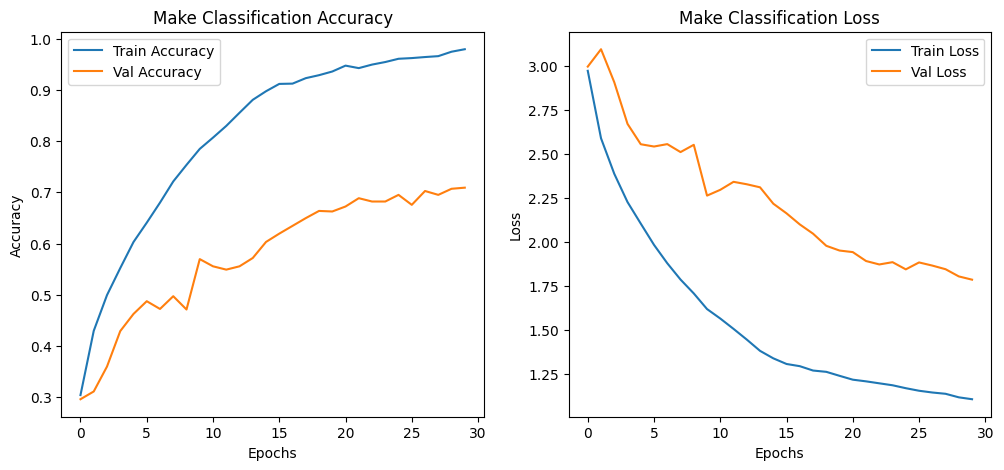


---Testing---
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.7330 - loss: 1.7823
Overall Test Loss: 1.7823
Overall Test Accuracy: 73.30%

15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 419ms/step
--- Classification Report ---
               precision    recall  f1-score   support

        acura       0.95      0.72      0.82        25
   alfa romeo       0.95      0.72      0.82        25
 aston martin       0.66      0.76      0.70        25
         audi       0.42      0.40      0.41        25
      bentley       0.70      0.92      0.79        25
          bmw       0.83      0.60      0.70        25
        buick       0.71      0.68      0.69        25
     cadillac       0.73      0.88      0.80        25
    chevrolet       0.79      0.60      0.68        25
     chrysler       0.75      0.96      0.84        25
        dodge       0.67      0.72      0.69        25
         fiat       0.89      0.96      0.92        25
         ford       0.57      0.64      0.60        25
          g

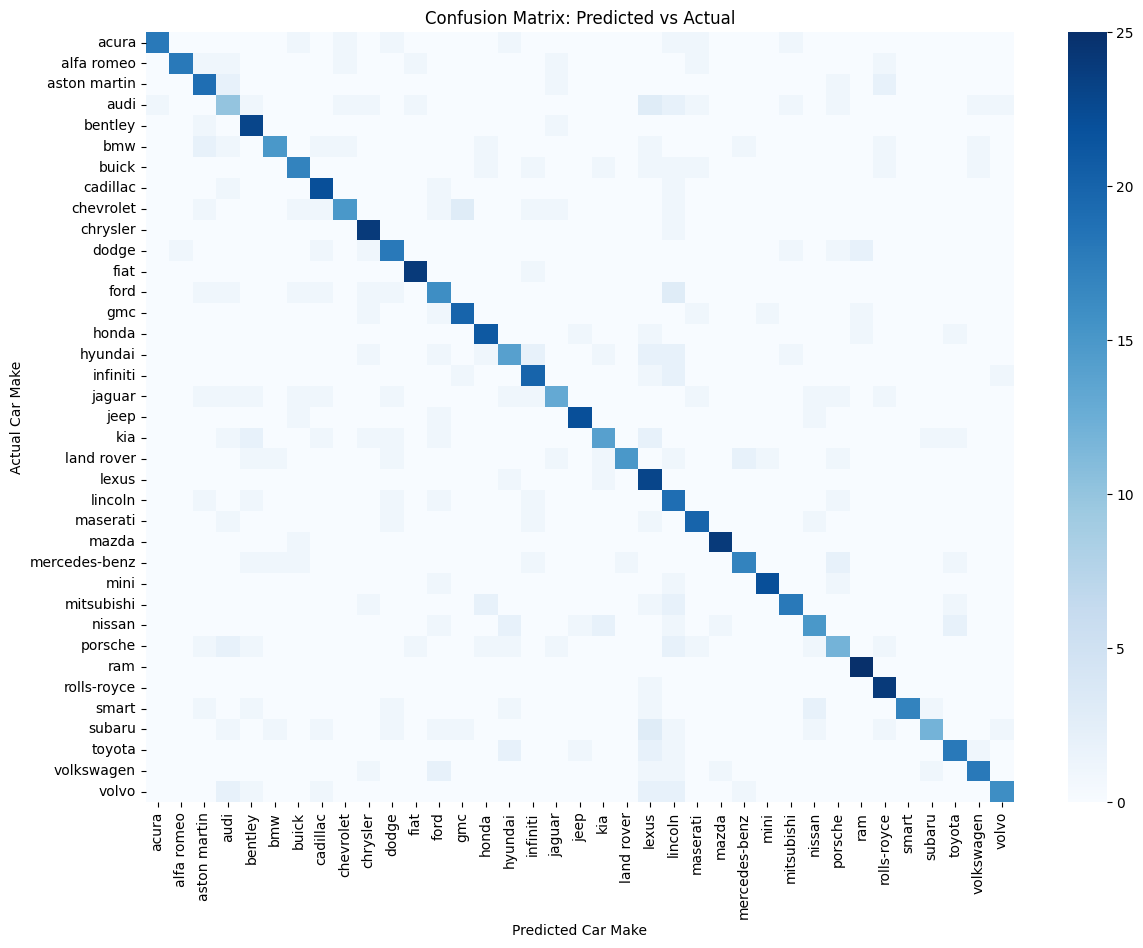

In [27]:
# Step 5 - Print out results

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_fine_tuned.history['accuracy'], label='Train Accuracy')
plt.plot(history_fine_tuned.history['val_accuracy'], label='Val Accuracy')
plt.title('Make Classification Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history_fine_tuned.history['loss'], label='Train Loss')
plt.plot(history_fine_tuned.history['val_loss'], label='Val Loss')
plt.title('Make Classification Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Testing
print("\n---Testing---")
test_results = model.evaluate(test_gen)
print(f"Overall Test Loss: {test_results[0]:.4f}")
print(f"Overall Test Accuracy: {test_results[1]*100:.2f}%\n")

test_gen.reset()

# Print out model's precision, recall, and f1-measures
y_pred_probs = model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

class_labels = list(test_gen.class_indices.keys())

print("--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Confusion Matrix Visuals
print("\n---Confusion Matrix for Testing---")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix: Predicted vs Actual')
plt.xlabel('Predicted Car Make')
plt.ylabel('Actual Car Make')
plt.show()

In [30]:
# Step 6 - Save the Model

import numpy as np

model.save("car_make_identifier_pretrained_cnn_model_with_mobilenetv2.keras")